# Part 1: Clustering with K-Means (Unsupervised Learning)

## Importing Libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Loading the Dataset

In [58]:
url = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(url)
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 519.7 KB
None
                                         Poster

## Data Preprocessing

In [59]:
df["Certificate"] = df["Certificate"].fillna("Not Rated")
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())

df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
df['Gross'] = df['Gross'].fillna(df['Gross'].median())

df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False)
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['No_of_Votes'] = pd.to_numeric(df['No_of_Votes'], errors='coerce')

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Poster_Link      0
Series_Title     0
Released_Year    1
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64


## Feature Group 1: Financial Metrics

Clustering by Gross revenue and Runtime. We inspect elbow + silhouette and select **k = 4** as a compact, interpretable split with strong separation.

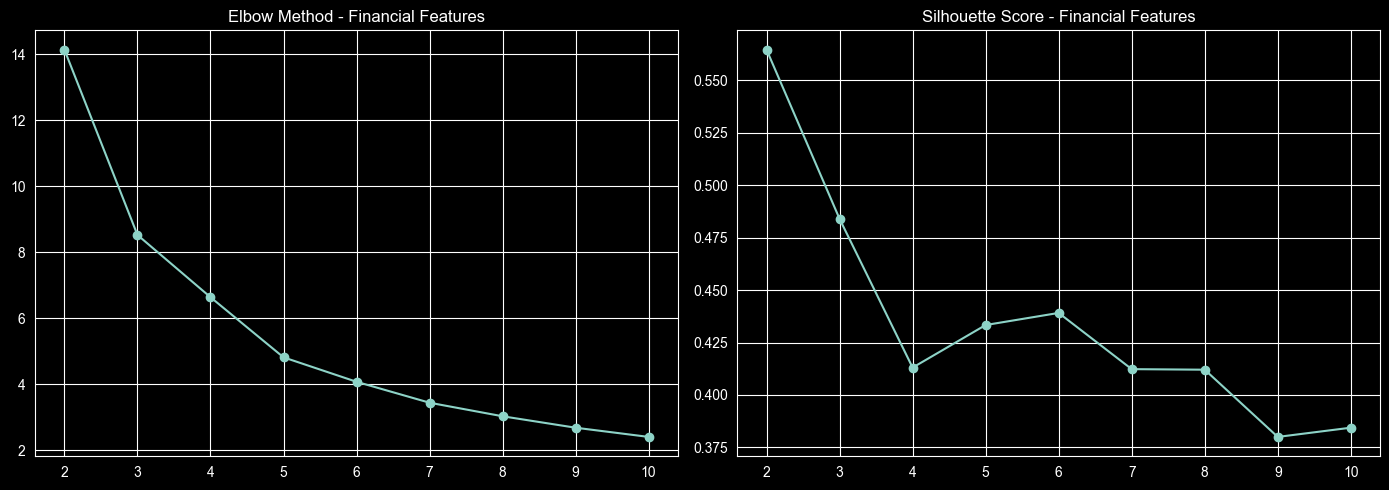

In [60]:
fin_features = ['Gross', 'Runtime']
df_fin = df[fin_features].dropna().copy()

scaler_fin = MinMaxScaler()
X_fin = scaler_fin.fit_transform(df_fin)

elbow_scors, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_fin)
    elbow_scors.append(km.inertia_)
    sil_scores.append(silhouette_score(X_fin, labels))

_ , axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, elbow_scors, marker='o')
axes[0].set_title('Elbow Method - Financial Features')
axes[1].plot(K_range, sil_scores, marker='o')
axes[1].set_title('Silhouette Score - Financial Features')
plt.tight_layout()
plt.show()

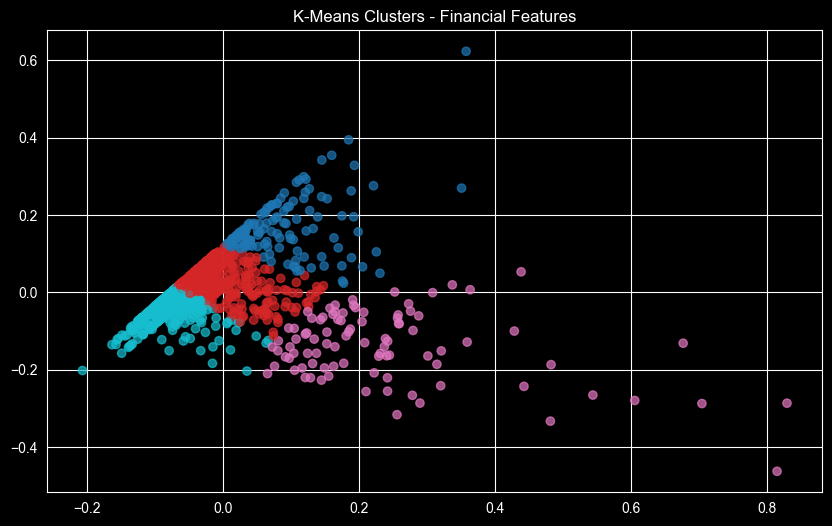

                Gross  Runtime
Cluster                       
0        4.408198e+07   174.16
1        4.286508e+07   128.87
2        3.188572e+08   126.28
3        2.280881e+07    99.24


In [61]:
k_fin = 4
km_fin = KMeans(n_clusters=k_fin, random_state=42, n_init=10)
df_fin['Cluster'] = km_fin.fit_predict(X_fin)

X_2d = PCA(n_components=2).fit_transform(X_fin)
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df_fin['Cluster'], cmap='tab10', alpha=0.7)
plt.title('K-Means Clusters - Financial Features')
plt.show()

print(df_fin.groupby('Cluster')[fin_features].mean().round(2))

## Feature Group 2: Quality Metrics

Clustering by IMDB Rating and Meta score. Elbow and silhouette indicate a small number of compact groups, so we use **k = 3**.

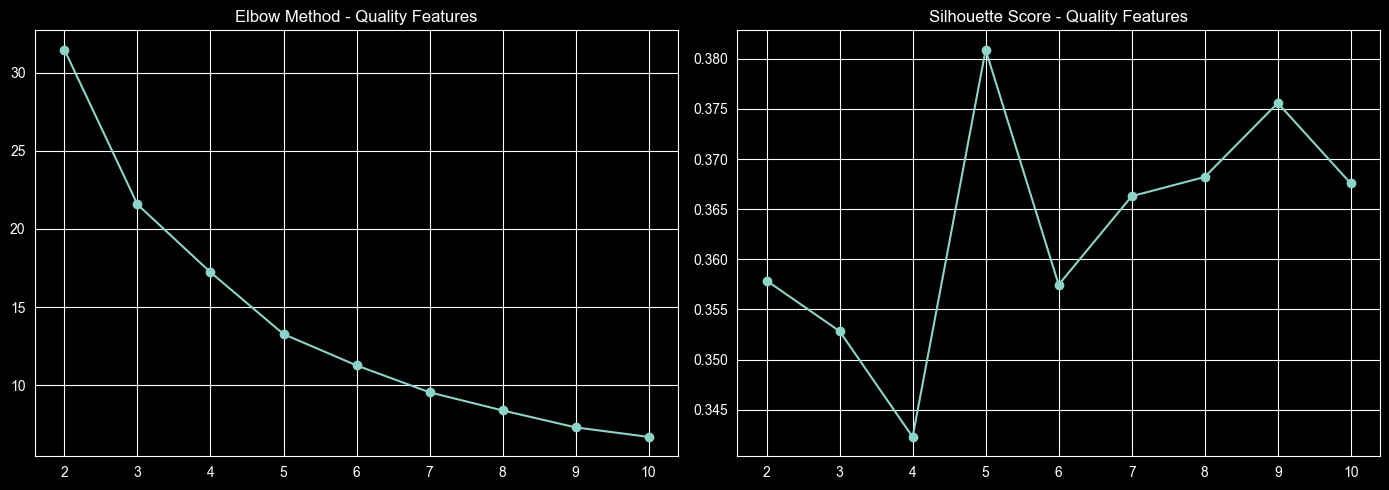

In [62]:
quality_features = ['IMDB_Rating', 'Meta_score']
df_qual = df[quality_features].dropna().copy()

scaler_qual = MinMaxScaler()
X_qual = scaler_qual.fit_transform(df_qual)

elbow_scores, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_qual)
    elbow_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_qual, labels))

_ , axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, elbow_scores, marker='o')
axes[0].set_title('Elbow Method - Quality Features')
axes[1].plot(K_range, sil_scores, marker='o')
axes[1].set_title('Silhouette Score - Quality Features')
plt.tight_layout()
plt.show()

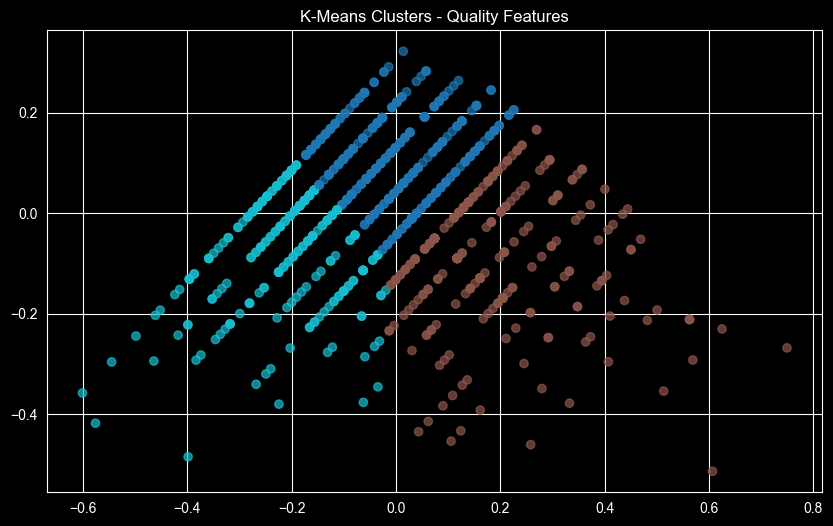

         IMDB_Rating  Meta_score
Cluster                         
0             7.8215     83.2975
1             8.2731     82.1489
2             7.7734     63.5861


In [63]:
k_qual = 3
km_qual = KMeans(n_clusters=k_qual, random_state=42, n_init=10)
df_qual['Cluster'] = km_qual.fit_predict(X_qual)

X_2d = PCA(n_components=2).fit_transform(X_qual)
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df_qual['Cluster'], cmap='tab10', alpha=0.7)
plt.title('K-Means Clusters - Quality Features')
plt.show()

print(df_qual.groupby('Cluster')[quality_features].mean().round(4))

## Feature Group 3: Popularity + Genre

Clustering by `No_of_Votes`, `IMDB_Rating`, and `Genres`.
Instead of keeping only the first genre, we split all genres per movie into separate binary columns (one per unique genre). This preserves full genre information - a movie tagged "Action, Drama" now contributes to both the `Action` and `Drama` columns. Given higher dimensionality, we keep **k = 5** for richer but still readable segments.

In [64]:
genre_dummies = df['Genre'].str.get_dummies(sep=', ')
print(f"Unique genres found: {genre_dummies.shape[1]}")
print(genre_dummies.sum().sort_values(ascending=False).head(10))  # most common genres

Unique genres found: 21
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
dtype: int64


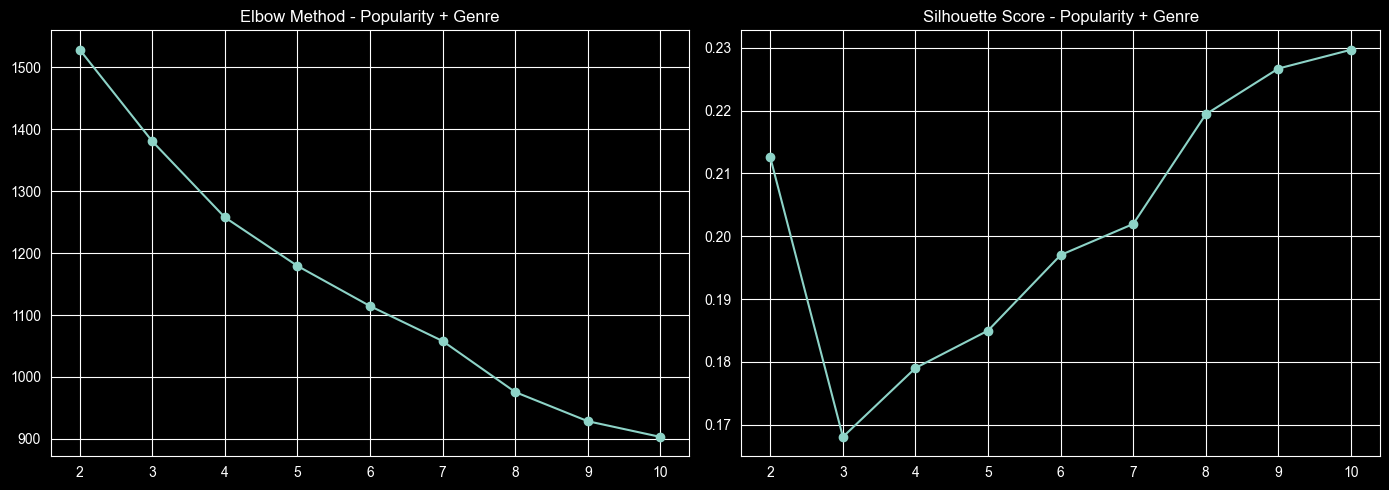

In [65]:
# Build feature matrix: votes + rating + all genre flags
pop_base = df[['No_of_Votes', 'IMDB_Rating']].copy()
pop_full = pd.concat([pop_base, genre_dummies], axis=1).dropna()

scaler_pop = MinMaxScaler()
X_pop = scaler_pop.fit_transform(pop_full)

elbow_scores, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pop)
    elbow_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pop, labels))

_ , axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, elbow_scores, marker='o')
axes[0].set_title('Elbow Method - Popularity + Genre')
axes[1].plot(K_range, sil_scores, marker='o')
axes[1].set_title('Silhouette Score - Popularity + Genre')
plt.tight_layout()
plt.show()

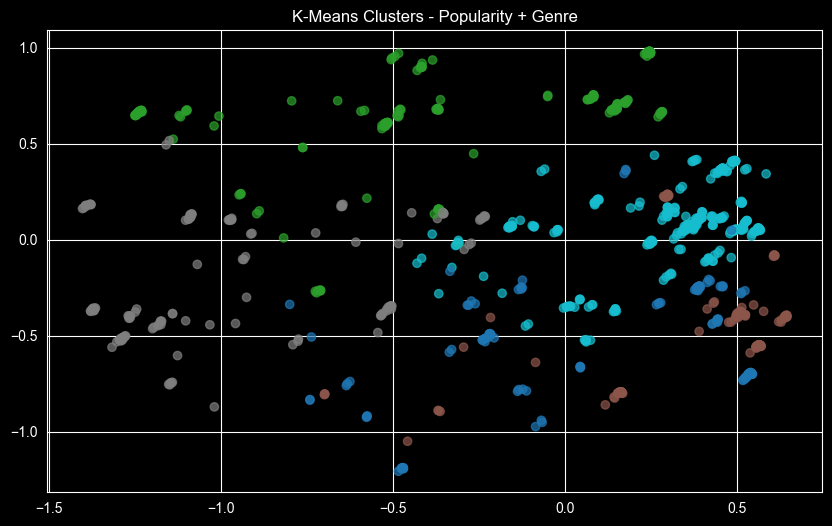

         No_of_Votes  IMDB_Rating                  Top_3_Genres
Cluster                                                        
0          295941.69         7.92        Thriller, Drama, Crime
1          212760.87         7.90        Comedy, Drama, Romance
2          275236.73         7.97          Crime, Drama, Action
3          497114.31         7.96  Adventure, Action, Animation
4          217527.26         7.98     Drama, Biography, Romance


In [66]:
k_pop = 5
km_pop = KMeans(n_clusters=k_pop, random_state=42, n_init=10)
pop_full = pop_full.copy()
pop_full['Cluster'] = km_pop.fit_predict(X_pop)

X_2d = PCA(n_components=2).fit_transform(X_pop)
plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pop_full['Cluster'], cmap='tab10', alpha=0.7)
plt.title('K-Means Clusters - Popularity + Genre')
plt.show()

# Cluster profiles: average votes and rating, top 3 genres per cluster
genre_cols = genre_dummies.columns.tolist()
profile = pop_full.groupby('Cluster')[['No_of_Votes', 'IMDB_Rating']].mean().round(2)
for cluster_id in range(k_pop):
    mask = pop_full['Cluster'] == cluster_id
    top_genres = pop_full.loc[mask, genre_cols].sum().nlargest(3).index.tolist()
    profile.loc[cluster_id, 'Top_3_Genres'] = ', '.join(top_genres)

print(profile)

## Cluster Interpretation

Using the selected values (`k_fin=4`, `k_qual=3`, `k_pop=5`), the financial clusters separate high-gross blockbusters from smaller films, with a broad middle tier.

The quality clusters reveal critic-aligned films (higher Meta score, moderate IMDB), crowd favorites (higher IMDB, lower Meta score), and a high-on-both group.

The popularity clusters reflect genuine genre composition alongside vote count. Clusters no longer collapse under a single dominant genre label - each cluster's top genres describe the content mix audiences gravitate toward.

# Part 2: Classification with Logistic Regression (Supervised Learning)

Logistic regression works by passing a linear combination of features through the sigmoid function to output a probability between 0 and 1. A threshold of 0.5 is then used to assign the final class label.

## Creating the Binary Target Variable

We define `Is_Profitable = 1` if a movie's Gross revenue is **above the dataset median**, otherwise 0.

Since the dataset does not include production budgets, absolute profit cannot be computed. Using the median gross as the threshold is a data-driven boundary: it splits the dataset into movies that out-earned at least half of all films (commercially successful) versus those that did not. This makes the target both interpretable and balanced by construction.

In [67]:
gross_median = df['Gross'].median()
df['Is_Profitable'] = (df['Gross'] > gross_median).astype(int)

print(f"Gross median threshold: ${gross_median:,.0f}")
print(df['Is_Profitable'].value_counts())
print(f"Positive class rate: {df['Is_Profitable'].mean():.1%}")

Gross median threshold: $23,530,892
Is_Profitable
0    585
1    415
Name: count, dtype: int64
Positive class rate: 41.5%


## Feature Engineering

To avoid leakage, we split first and encode person features using **training data only**.
`Director` and `Star1` are converted to numeric values using the training-set mean of `Is_Profitable` per category, then applied to test with a global fallback.
We also include rating, vote count, runtime, release year, Meta score, and the genre features built in Part 1.

In [68]:
person_cols = ['Director', 'Star1']
base_features = ['Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes',
                 'Released_Year', 'Director', 'Star1']
cls_features = base_features + genre_cols

df_model = pd.concat(
    [df[base_features + ['Is_Profitable']], genre_dummies],
    axis=1
).dropna()

print(f"Samples available: {len(df_model)}")

Samples available: 999


## Training the Model

In [69]:
X = df_model[cls_features].copy()
y = df_model['Is_Profitable'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

min_count = 5
for col in person_cols:
    train_counts = X_train[col].value_counts()
    keep = set(train_counts[train_counts >= min_count].index)

    X_train[col] = X_train[col].where(X_train[col].isin(keep), 'Rare_Unknown')
    X_test[col] = X_test[col].where(X_test[col].isin(keep), 'Rare_Unknown')

    freq_map = X_train[col].value_counts(normalize=True)
    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map).fillna(freq_map.get('Rare_Unknown', 0.0))

scaler_cls = MinMaxScaler()
X_train_sc = scaler_cls.fit_transform(X_train)
X_test_sc = scaler_cls.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)

y_pred = lr.predict(X_test_sc)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8350


## Evaluation

                    precision    recall  f1-score   support

Below Median Gross       0.88      0.84      0.86       117
Above Median Gross       0.78      0.83      0.81        83

          accuracy                           0.83       200
         macro avg       0.83      0.83      0.83       200
      weighted avg       0.84      0.83      0.84       200



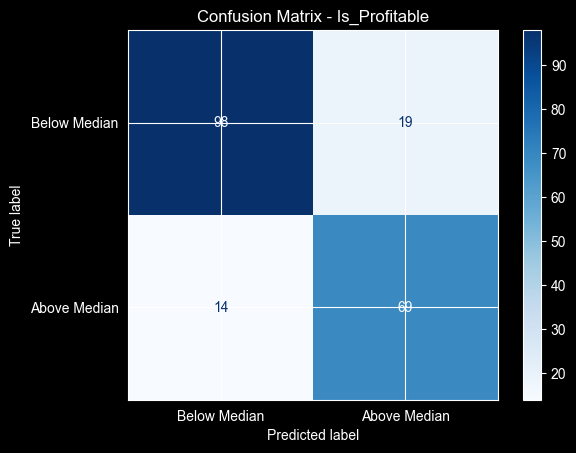

In [70]:
print(classification_report(y_test, y_pred, target_names=['Below Median Gross', 'Above Median Gross']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below Median', 'Above Median'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Is_Profitable')
plt.show()

## Coefficient Interpretation

Positive coefficients push the prediction toward "above median gross" (profitable); negative ones push toward "below median gross".  


Top 10 positive predictors:
      Feature  Coefficient
  No_of_Votes     8.373017
      Runtime     1.592097
    Biography     0.873527
       Family     0.647589
    Adventure     0.618632
Released_Year     0.593611
       Sci-Fi     0.392550
          War     0.337184
      History     0.274349
     Director     0.244230

Top 10 negative predictors:
    Feature  Coefficient
    Romance    -0.081585
    Musical    -0.164922
      Star1    -0.185430
    Mystery    -0.210834
  Animation    -0.247586
     Horror    -0.317152
      Drama    -0.365141
 Meta_score    -0.517793
  Film-Noir    -0.992348
IMDB_Rating    -2.753488


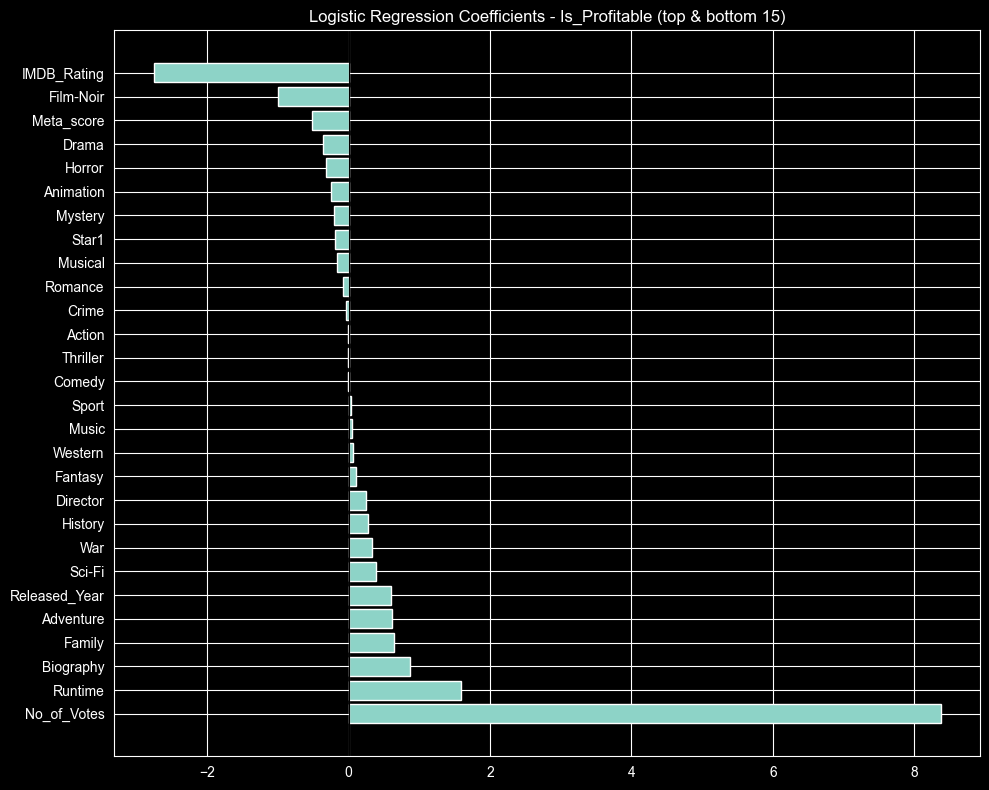

In [71]:
coef_df = pd.DataFrame({
    'Feature': cls_features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 positive predictors:")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 negative predictors:")
print(coef_df.tail(10).to_string(index=False))

# Plot top & bottom 15
top_bottom = pd.concat([coef_df.head(15), coef_df.tail(15)]).drop_duplicates()
plt.figure(figsize=(10, 8))
plt.barh(top_bottom['Feature'], top_bottom['Coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients - Is_Profitable (top & bottom 15)')
plt.tight_layout()
plt.show()

# Part 3: Reflection and Insights

The financial clustering from Part 1 remained the most relevant group for this task: with `k_fin=4`, it separated clear gross tiers that align with the supervised boundary.

`IMDB_Rating` and `Meta_score` still carried modest coefficients, matching the `k_qual=3` result: quality signals alone do not strongly predict box-office outcomes.

**Comparing the three clustering groups:** the financial cluster was most informative, the quality cluster least relevant, and the popularity cluster (`k_pop=5`) intermediate because vote count and genre mix better reflect audience reach.

**Suggested improvements:**
- Log-transforming `Gross` and `No_of_Votes` before scaling would reduce the influence of extreme outliers (a handful of blockbusters skew both distributions heavily).
- A Random Forest or Gradient Boosting model would likely outperform Logistic Regression here, since the relationship between star power and gross is non-linear.